# Bonus Task: Neural Network Regression with PyTorch

**Course:** Introduction to Artificial Intelligence  
**Dataset:** Auto MPG  


**Colab Execution Note**

This notebook is intended for execution in Google Colab.

Please enable GPU if available, run the setup cells, load the Auto MPG dataset, perform model selection using the validation set, and evaluate on the test set only after selecting the final configuration.

## Notebook Structure

This notebook is organized into the following parts:

1. Data preparation and loading for the Auto MPG regression task.
2. Definition of the neural network model and training utilities.
3. Validation-based comparison of several training configurations.
4. Final model selection and evaluation on the held-out test set.

The notebook is adapted from the PyTorch classification notebook, but modified here for regression.

## Environment Setup

In this section, we import the required packages, define the computation device, and prepare the notebook for neural network regression experiments.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

USE_GPU = True
dtype = torch.float32  # We will use float tensors throughout this notebook.

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# Constant to control how frequently we print training progress.
print_every = 100
print('using device:', device)

using device: cpu


# Part I. Preparation

In this section, we load and preprocess the Auto MPG dataset for the neural network regression task.

We construct the feature matrix, define the target variable `mpg`, and split the data into training, validation, and test sets.

In [2]:
import os
from urllib.request import urlopen

column_names = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin"
]

local_path = "auto-mpg.data"
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

if os.path.exists(local_path):
    with open(local_path, "r", encoding="utf-8") as f:
        lines = f.readlines()
else:
    with urlopen(url) as response:
        lines = [line.decode("utf-8") for line in response.readlines()]

rows = []
for line in lines:
    parts = line.strip().split(maxsplit=8)
    if len(parts) >= 8:
        rows.append(parts[:8])

df = pd.DataFrame(rows, columns=column_names)
df = df.replace("?", np.nan)

for col in column_names:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna().reset_index(drop=True)

X = df.drop(columns=["mpg"]).copy()
y = df["mpg"].copy()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=dtype)
X_val_tensor = torch.tensor(X_val_scaled, dtype=dtype)
X_test_tensor = torch.tensor(X_test_scaled, dtype=dtype)

y_train_tensor = torch.tensor(y_train.to_numpy().reshape(-1, 1), dtype=dtype)
y_val_tensor = torch.tensor(y_val.to_numpy().reshape(-1, 1), dtype=dtype)
y_test_tensor = torch.tensor(y_test.to_numpy().reshape(-1, 1), dtype=dtype)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

loader_train = DataLoader(train_dataset, batch_size=64, shuffle=True)
loader_val = DataLoader(val_dataset, batch_size=64, shuffle=False)
loader_test = DataLoader(test_dataset, batch_size=64, shuffle=False)

input_dim = X_train_tensor.shape[1]

print("Dataset loaded successfully.")
print(f"Full dataset shape: {df.shape}")
print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}, Test shape: {X_test.shape}")
print(f"Number of input features: {input_dim}")

df.head()

Dataset loaded successfully.
Full dataset shape: (392, 8)
Train shape: (250, 7), Validation shape: (63, 7), Test shape: (79, 7)
Number of input features: 7


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


# Main Experimental Section: Auto MPG Model Development

In this section, we perform the main experimental work for the bonus regression task.

We compare several neural network configurations for Auto MPG, select hyperparameters using validation performance only, and keep the test set untouched until the final evaluation.

Our goals in this section are:
1. Compare several model architectures and training configurations.
2. Select the best configuration using validation performance.
3. Keep the test set for final evaluation only.
4. Summarize what we learned from the comparisons.

### Experiment Utilities

In this section, we define helper functions for validation-based model evaluation and experiment tracking for the Auto MPG regression task.

These utilities will be used in the following experiments to compare several neural network configurations, select the best model using validation performance only, and keep the test set untouched until the final evaluation.

In [3]:
import copy
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


def evaluate_regression_model(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_samples = 0

    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=dtype)

            preds = model(x)
            loss = loss_fn(preds, y)

            total_loss += loss.item() * x.size(0)
            total_samples += x.size(0)

            y_true_all.append(y.cpu().numpy())
            y_pred_all.append(preds.cpu().numpy())

    y_true_all = np.vstack(y_true_all).ravel()
    y_pred_all = np.vstack(y_pred_all).ravel()

    mse = np.mean((y_true_all - y_pred_all) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true_all - y_pred_all))

    return {
        "loss": total_loss / total_samples,
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "y_true": y_true_all,
        "y_pred": y_pred_all
    }


def run_regression_experiment(model, optimizer, loss_fn, train_loader, val_loader, epochs=100, model_name="model"):
    model = model.to(device=device)

    history = {
        "model_name": model_name,
        "train_loss": [],
        "val_loss": [],
        "val_rmse": [],
        "val_mae": []
    }

    best_val_rmse = float("inf")
    best_state = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_samples = 0

        for x, y in train_loader:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=dtype)

            optimizer.zero_grad()
            preds = model(x)
            loss = loss_fn(preds, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            running_samples += x.size(0)

        train_loss = running_loss / running_samples
        val_metrics = evaluate_regression_model(model, val_loader, loss_fn)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_rmse"].append(val_metrics["rmse"])
        history["val_mae"].append(val_metrics["mae"])

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_rmse={val_metrics['rmse']:.4f} | "
            f"val_mae={val_metrics['mae']:.4f}"
        )

        if val_metrics["rmse"] < best_val_rmse:
            best_val_rmse = val_metrics["rmse"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, history

### First Comparison Round

In this section, we perform a first comparison round between several neural network regression models for the Auto MPG dataset.

At this stage, we compare different architectural and optimization choices using validation performance only. The test set remains untouched and will be used only after the final model has been selected.

In [4]:
class LinearRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.net(x)


class MLPRegressorSmall(nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)


class MLPRegressorRegularized(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        return self.net(x)


loss_fn = nn.MSELoss()

experiment_configs = [
    {
        "name": "linear_sgd",
        "model": LinearRegressor(input_dim),
        "optimizer": lambda model: optim.SGD(model.parameters(), lr=1e-2)
    },
    {
        "name": "mlp_small_adam",
        "model": MLPRegressorSmall(input_dim, hidden_dim=32),
        "optimizer": lambda model: optim.Adam(model.parameters(), lr=1e-3)
    },
    {
        "name": "mlp_regularized_adam",
        "model": MLPRegressorRegularized(input_dim, hidden1=64, hidden2=32, dropout=0.2),
        "optimizer": lambda model: optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    }
]

all_histories = []
results_summary = []

best_model = None
best_history = None
best_name = None
best_val_rmse = float("inf")

### First Experimental Comparison

We now run the first comparison round between the selected regression model configurations.

Model selection in this stage is based on validation RMSE only. The model with the lowest validation RMSE will be selected as the current best candidate.

In [5]:
for config in experiment_configs:
    print("=" * 80)
    print(f"Running experiment: {config['name']}")

    current_model = config["model"]
    current_optimizer = config["optimizer"](current_model)

    trained_model, history = run_regression_experiment(
        current_model,
        current_optimizer,
        loss_fn,
        loader_train,
        loader_val,
        epochs=80,
        model_name=config["name"]
    )

    current_best_val_loss = min(history["val_loss"])
    current_best_val_rmse = min(history["val_rmse"])
    current_best_val_mae = min(history["val_mae"])

    history["best_val_loss"] = current_best_val_loss
    history["best_val_rmse"] = current_best_val_rmse
    history["best_val_mae"] = current_best_val_mae

    all_histories.append(history)

    results_summary.append({
        "name": config["name"],
        "best_val_loss": current_best_val_loss,
        "best_val_rmse": current_best_val_rmse,
        "best_val_mae": current_best_val_mae
    })

    print(
        f"Finished {config['name']} | "
        f"best_val_loss={current_best_val_loss:.4f} | "
        f"best_val_rmse={current_best_val_rmse:.4f} | "
        f"best_val_mae={current_best_val_mae:.4f}"
    )

    if current_best_val_rmse < best_val_rmse:
        best_val_rmse = current_best_val_rmse
        best_model = trained_model
        best_history = history
        best_name = config["name"]

print("\n" + "=" * 80)
print("Validation summary:")
for result in results_summary:
    print(
        f"{result['name']}: "
        f"best_val_loss={result['best_val_loss']:.4f}, "
        f"best_val_rmse={result['best_val_rmse']:.4f}, "
        f"best_val_mae={result['best_val_mae']:.4f}"
    )

print("\nBest model selected by validation RMSE:")
print(f"{best_name} with best_val_rmse={best_val_rmse:.4f}")

Running experiment: linear_sgd
Epoch 1/80 | train_loss=586.6111 | val_loss=480.1241 | val_rmse=21.9117 | val_mae=21.2032
Epoch 2/80 | train_loss=481.5655 | val_loss=402.4137 | val_rmse=20.0603 | val_mae=19.5590
Epoch 3/80 | train_loss=403.9688 | val_loss=340.4391 | val_rmse=18.4510 | val_mae=18.0335
Epoch 4/80 | train_loss=341.8505 | val_loss=289.1704 | val_rmse=17.0050 | val_mae=16.6250
Epoch 5/80 | train_loss=290.3949 | val_loss=246.6219 | val_rmse=15.7042 | val_mae=15.3246
Epoch 6/80 | train_loss=248.4136 | val_loss=210.7935 | val_rmse=14.5187 | val_mae=14.1237
Epoch 7/80 | train_loss=213.0372 | val_loss=180.4615 | val_rmse=13.4336 | val_mae=13.0157
Epoch 8/80 | train_loss=183.0631 | val_loss=154.7084 | val_rmse=12.4382 | val_mae=11.9927
Epoch 9/80 | train_loss=157.6140 | val_loss=132.7640 | val_rmse=11.5223 | val_mae=11.0477
Epoch 10/80 | train_loss=136.0298 | val_loss=114.1283 | val_rmse=10.6831 | val_mae=10.1759
Epoch 11/80 | train_loss=117.7440 | val_loss=98.2319 | val_rmse=9.91

### Visual Comparison of the First Round

We now visualize the first comparison round using training loss, validation loss, and validation RMSE curves.

These plots help us compare convergence behavior, generalization, and overall validation performance across the candidate regression models.

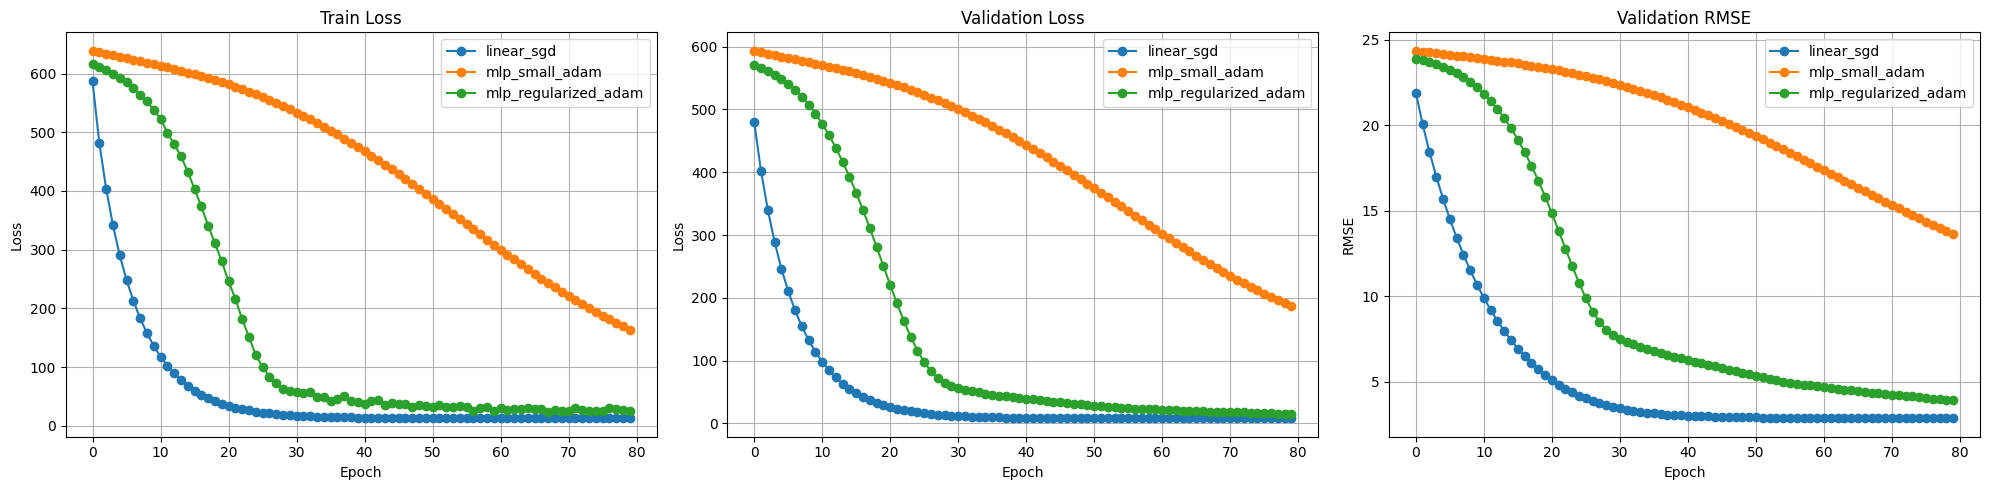

In [6]:
import matplotlib.pyplot as plt

assert "all_histories" in globals(), "all_histories is not defined. Please run the first comparison cell first."

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

metrics = ["train_loss", "val_loss", "val_rmse"]
titles = ["Train Loss", "Validation Loss", "Validation RMSE"]
ylabels = ["Loss", "Loss", "RMSE"]

for ax, metric, title, ylabel in zip(axes, metrics, titles, ylabels):
    for history in all_histories:
        ax.plot(history[metric], marker='o', label=history["model_name"])
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

### Interpretation of the First Comparison Round

The first comparison round provides a clear initial picture of model behavior on the Auto MPG regression task.

Among the three candidate models, the linear baseline trained with SGD achieved the best validation performance, reaching the lowest validation RMSE. This indicates that, at least at this stage of the experiment, a simple linear model provides a very strong baseline for this dataset.

The two neural network models behaved differently. The small MLP improved very slowly and remained substantially worse than the linear model throughout the experiment, suggesting that this configuration is not well suited to the task in its current form. The regularized MLP performed much better than the small MLP and showed a clear reduction in both validation loss and validation RMSE, but it still did not outperform the linear baseline.

Overall, the first comparison round suggests that the strongest direction at this point is the linear baseline, while also motivating a more focused search to determine whether a better neural network configuration can close the gap.

### Refined Search

After the first comparison round, we now perform a more focused search around the strongest directions identified so far.

In this stage, we compare several configurations based on hidden size, optimizer, learning rate, dropout, and weight decay, while continuing to use validation RMSE as the model selection criterion.

In [7]:
class MLPRegressorFlexible(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, dropout=0.0):
        super().__init__()
        layers = [
            nn.Linear(input_dim, hidden1),
            nn.ReLU()
        ]

        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        layers.extend([
            nn.Linear(hidden1, hidden2),
            nn.ReLU()
        ])

        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(hidden2, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [8]:
refined_configs = []

refined_configs.append({
    "name": "linear_adam_lr1e2",
    "model": LinearRegressor(input_dim),
    "optimizer": lambda model: optim.Adam(model.parameters(), lr=1e-2)
})

refined_configs.append({
    "name": "linear_adam_lr5e3",
    "model": LinearRegressor(input_dim),
    "optimizer": lambda model: optim.Adam(model.parameters(), lr=5e-3)
})
refined_configs.append({
    "name": "mlp_64_32_adam_lr1e3",
    "model": MLPRegressorFlexible(input_dim, hidden1=64, hidden2=32, dropout=0.0),
    "optimizer": lambda model: optim.Adam(model.parameters(), lr=1e-3)
})

refined_configs.append({
    "name": "mlp_64_32_adam_lr5e3",
    "model": MLPRegressorFlexible(input_dim, hidden1=64, hidden2=32, dropout=0.0),
    "optimizer": lambda model: optim.Adam(model.parameters(), lr=5e-3)
})
refined_configs.append({
    "name": "mlp_128_64_adam_lr1e3",
    "model": MLPRegressorFlexible(input_dim, hidden1=128, hidden2=64, dropout=0.0),
    "optimizer": lambda model: optim.Adam(model.parameters(), lr=1e-3)
})

refined_configs.append({
    "name": "mlp_128_64_adam_lr1e3_do01_wd1e4",
    "model": MLPRegressorFlexible(input_dim, hidden1=128, hidden2=64, dropout=0.1),
    "optimizer": lambda model: optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
})
refined_histories = []
refined_results_summary = []

best_refined_model = None
best_refined_history = None
best_refined_name = None
best_refined_val_rmse = float("inf")

### Second Experimental Comparison

We now run the refined comparison round between the selected regression model configurations.

Model selection in this stage continues to rely on validation RMSE only. The configuration with the lowest validation RMSE will be selected as the best refined candidate.

In [9]:
for cfg in refined_configs:
    print("=" * 80)
    print(f"Running refined config: {cfg['name']}")

    current_model = cfg["model"]
    current_optimizer = cfg["optimizer"](current_model)

    trained_model, history = run_regression_experiment(
        current_model,
        current_optimizer,
        loss_fn,
        loader_train,
        loader_val,
        epochs=80,
        model_name=cfg["name"]
    )

    current_best_val_loss = min(history["val_loss"])
    current_best_val_rmse = min(history["val_rmse"])
    current_best_val_mae = min(history["val_mae"])

    history["best_val_loss"] = current_best_val_loss
    history["best_val_rmse"] = current_best_val_rmse
    history["best_val_mae"] = current_best_val_mae

    refined_histories.append(history)

    refined_results_summary.append({
        "name": cfg["name"],
        "best_val_loss": current_best_val_loss,
        "best_val_rmse": current_best_val_rmse,
        "best_val_mae": current_best_val_mae
    })

    print(
        f"Finished {cfg['name']} | "
        f"best_val_loss={current_best_val_loss:.4f} | "
        f"best_val_rmse={current_best_val_rmse:.4f} | "
        f"best_val_mae={current_best_val_mae:.4f}"
    )

    if current_best_val_rmse < best_refined_val_rmse:
        best_refined_val_rmse = current_best_val_rmse
        best_refined_model = trained_model
        best_refined_history = history
        best_refined_name = cfg["name"]

print("\n" + "=" * 80)
print("Refined validation summary:")
for result in refined_results_summary:
    print(
        f"{result['name']}: "
        f"best_val_loss={result['best_val_loss']:.4f}, "
        f"best_val_rmse={result['best_val_rmse']:.4f}, "
        f"best_val_mae={result['best_val_mae']:.4f}"
    )

print("\nBest refined model selected by validation RMSE:")
print(f"{best_refined_name} with best_val_rmse={best_refined_val_rmse:.4f}")

Running refined config: linear_adam_lr1e2
Epoch 1/80 | train_loss=612.0782 | val_loss=567.5955 | val_rmse=23.8243 | val_mae=22.8713
Epoch 2/80 | train_loss=607.2006 | val_loss=563.9420 | val_rmse=23.7475 | val_mae=22.8345
Epoch 3/80 | train_loss=602.7176 | val_loss=560.3464 | val_rmse=23.6716 | val_mae=22.7982
Epoch 4/80 | train_loss=597.9434 | val_loss=556.8669 | val_rmse=23.5980 | val_mae=22.7618
Epoch 5/80 | train_loss=593.6013 | val_loss=553.4388 | val_rmse=23.5253 | val_mae=22.7254
Epoch 6/80 | train_loss=589.3205 | val_loss=550.0921 | val_rmse=23.4540 | val_mae=22.6892
Epoch 7/80 | train_loss=585.2125 | val_loss=546.7957 | val_rmse=23.3837 | val_mae=22.6526
Epoch 8/80 | train_loss=581.1068 | val_loss=543.6011 | val_rmse=23.3153 | val_mae=22.6162
Epoch 9/80 | train_loss=577.3559 | val_loss=540.4600 | val_rmse=23.2478 | val_mae=22.5799
Epoch 10/80 | train_loss=573.1003 | val_loss=537.4990 | val_rmse=23.1840 | val_mae=22.5436
Epoch 11/80 | train_loss=569.4045 | val_loss=534.5876 | v

### Visual Comparison of the Refined Search

We now visualize the refined comparison round using training loss, validation loss, and validation RMSE curves.

These plots help us compare the effect of the refined hyperparameter choices and support the final validation-based model selection.

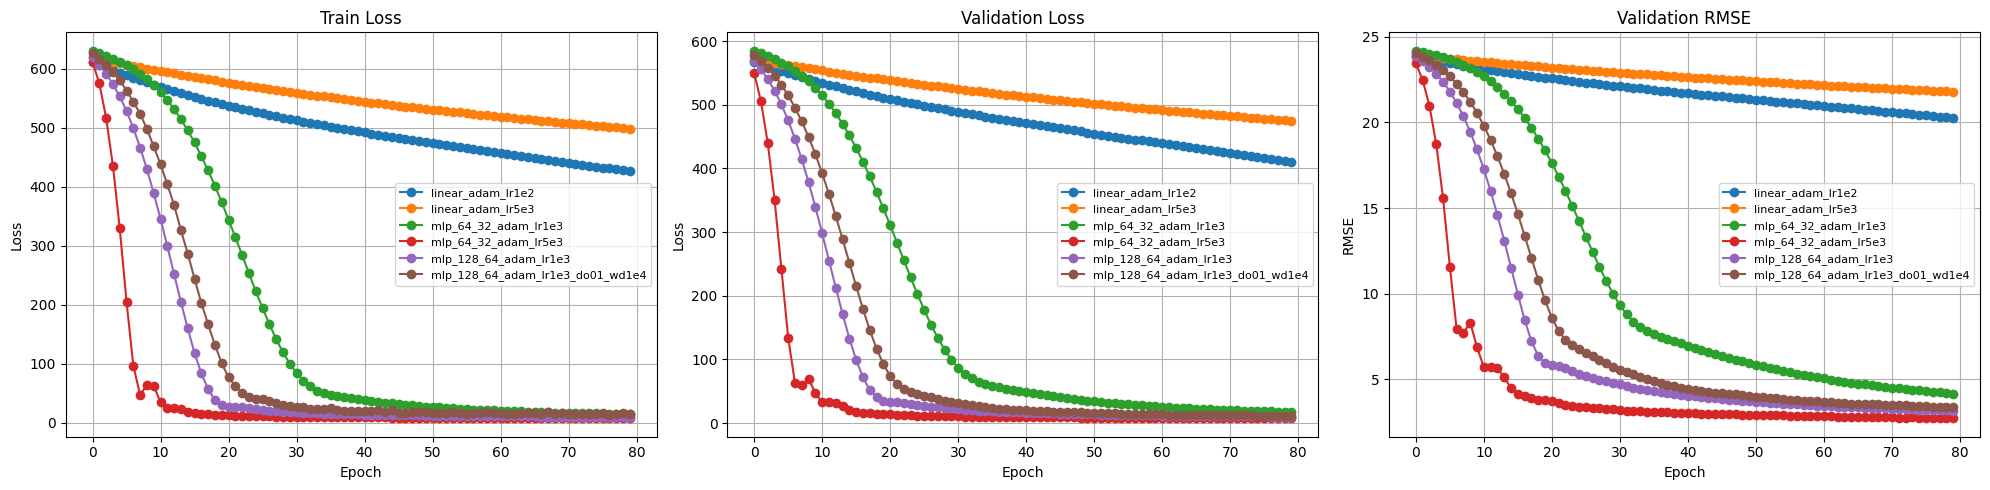

In [10]:
import matplotlib.pyplot as plt

assert "refined_histories" in globals(), "refined_histories is not defined. Please run the refined comparison cell first."

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

metrics = ["train_loss", "val_loss", "val_rmse"]
titles = ["Train Loss", "Validation Loss", "Validation RMSE"]
ylabels = ["Loss", "Loss", "RMSE"]

for ax, metric, title, ylabel in zip(axes, metrics, titles, ylabels):
    for history in refined_histories:
        ax.plot(history[metric], marker='o', label=history["model_name"])
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Interpretation of the Refined Search

The refined search produced a clear improvement over the first comparison round.

Unlike the initial results, where the linear baseline achieved the best validation RMSE, the refined comparison identified a neural network configuration that performed better. In particular, the model `mlp_64_32_adam_lr5e3` achieved the lowest validation RMSE, reaching `2.7245`, and therefore became the leading candidate for final evaluation.

The plots also show that the refined search was meaningful. The two linear models trained with Adam remained substantially worse than the neural network alternatives, while several MLP configurations improved considerably after tuning the architecture and optimization settings. Among them, `mlp_64_32_adam_lr5e3` showed the fastest and strongest reduction in validation RMSE.

Overall, the refined search supports the conclusion that validation-based hyperparameter tuning was necessary and effective, and it justifies selecting `mlp_64_32_adam_lr5e3` as the final candidate for test evaluation.

### Final Evaluation on the Held-Out Test Set

After completing model selection using validation performance only, we now evaluate the selected configuration on the held-out test set.

This is the first and only use of the test set in this notebook.

In [11]:
assert best_refined_model is not None, "best_refined_model is None. Please run the refined search cell first."

final_model = best_refined_model
final_model_name = best_refined_name
final_val_rmse = best_refined_val_rmse

final_test_metrics = evaluate_regression_model(final_model, loader_test, loss_fn)

print("=" * 80)
print("Final evaluation on the held-out test set")
print(f"Selected model: {final_model_name}")
print(f"Best validation RMSE used for selection: {final_val_rmse:.4f}")
print(f"Test loss: {final_test_metrics['loss']:.4f}")
print(f"Test RMSE: {final_test_metrics['rmse']:.4f}")
print(f"Test MAE: {final_test_metrics['mae']:.4f}")

Final evaluation on the held-out test set
Selected model: mlp_64_32_adam_lr5e3
Best validation RMSE used for selection: 2.7245
Test loss: 7.1686
Test RMSE: 2.6774
Test MAE: 1.8612


### Interpretation of the Final Test Evaluation

After selecting the final model using validation RMSE only, we evaluated it once on the held-out test set.

The selected model, `mlp_64_32_adam_lr5e3`, achieved a test RMSE of `2.6774` and a test MAE of `1.8612`. These results are close to the corresponding validation RMSE used during model selection, which suggests that the selected configuration generalizes well and that the validation-based tuning procedure was effective.

Overall, the final test result supports the conclusion that a carefully tuned neural network can provide strong regression performance on the Auto MPG dataset. In particular, the refined MLP configuration outperformed the earlier linear baseline and became the best overall model in this notebook.

### Predicted Values vs True Values

To better understand the final model performance, we now compare the predicted MPG values with the true MPG values on the held-out test set.

This plot provides a direct visual assessment of regression quality and is one of the required figures for the bonus task.

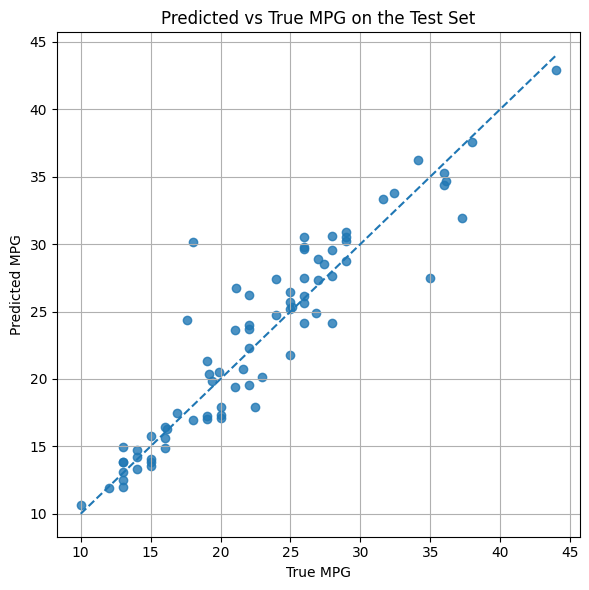

In [12]:
assert "final_test_metrics" in globals(), "final_test_metrics is not defined. Please run the final test evaluation cell first."

y_true = final_test_metrics["y_true"]
y_pred = final_test_metrics["y_pred"]

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.8)

min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True MPG")
plt.ylabel("Predicted MPG")
plt.title("Predicted vs True MPG on the Test Set")
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation of the Predicted vs True Plot

The predicted versus true MPG plot provides a direct visual summary of the final model performance on the held-out test set.

Most of the points lie reasonably close to the diagonal reference line, which indicates that the predicted values are generally close to the true MPG values. This suggests that the model captures the main relationship between the input features and the regression target.

There is still some spread around the diagonal, especially for several medium and high MPG examples, which reflects the remaining prediction error. However, the overall pattern is clearly aligned with the ideal prediction line, supporting the conclusion that the final model generalizes well and provides strong regression performance on the Auto MPG dataset.